In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
methods = [
    {
        'name': 'vgg',
        'model': 'VGG16',
    },
    {
        'name': 'resnet',
        'model': 'ResNet18',
    },
    {
        'name': 'resnet_sigmoid',
        'model': 'ResNet18 (Sigmoid)',
    },
    {
        'name': 'vqa',
        'model': 'VQA',
    },
]

dfs = []

for method in methods:
    # Load the predictions
    preds = pd.read_csv(f'preds_{method["name"]}.csv')
    preds = preds.rename(columns={'has_cactus': f'{method["name"]}_preds'})
    preds = preds.set_index('id')

    dfs.append(preds)

# Join the predictions
joined: pd.DataFrame = dfs.pop()
for df in dfs:
    joined = joined.join(df)

joined

,vqa_preds,vgg_preds,resnet_preds,resnet_sigmoid_preds
id,,,,
4da1b14cc17bcdb63ff39102d72a6238.jpg,0,1,1,1
78a77ebf391ee847d637e719b9db4e9a.jpg,0,1,1,1
9bbb892106127afd3608c87ca84cf199.jpg,0,1,1,1
5bd075d8253c53e99c6e73ac4172ac8b.jpg,0,0,0,0
c61cec0105f9a1cbdc569af8676abb2a.jpg,0,1,1,1
...,...,...,...,...
06e393e669d7651e2d93559ca0936305.jpg,0,1,1,1
dedfd928d59a9b49a129db3a9a5c7b04.jpg,0,0,0,0
23f015d93a0a38b7951cd306c767d80c.jpg,0,0,0,0


In [3]:
equals = (joined['vgg_preds'] == joined['resnet_preds']).sum()
total = len(joined)
print(f'VGG and ResNet agree on {equals} out of {total} test images. ({equals / total:.2%})')

VGG and ResNet agree on 3822 out of 4000 test images. (95.55%)


In [4]:
G = nx.Graph()

for i, method in enumerate(methods):
    for cmethod in methods[i + 1:]:
        equals = (joined[f'{method["name"]}_preds'] == joined[f'{cmethod["name"]}_preds']).sum()
        total = len(joined)
        agree = equals / total
        print(f'{method["model"]} and {cmethod["model"]} agree on {equals} out of {total} test images. ({agree:.2%})')

        G.add_edge(method['model'], cmethod['model'], weight=agree, wperc=f"{agree:.2%}")

VGG16 and ResNet18 agree on 3822 out of 4000 test images. (95.55%)
VGG16 and ResNet18 (Sigmoid) agree on 3809 out of 4000 test images. (95.23%)
VGG16 and VQA agree on 1052 out of 4000 test images. (26.30%)
ResNet18 and ResNet18 (Sigmoid) agree on 3891 out of 4000 test images. (97.28%)
ResNet18 and VQA agree on 1114 out of 4000 test images. (27.85%)
ResNet18 (Sigmoid) and VQA agree on 1129 out of 4000 test images. (28.23%)


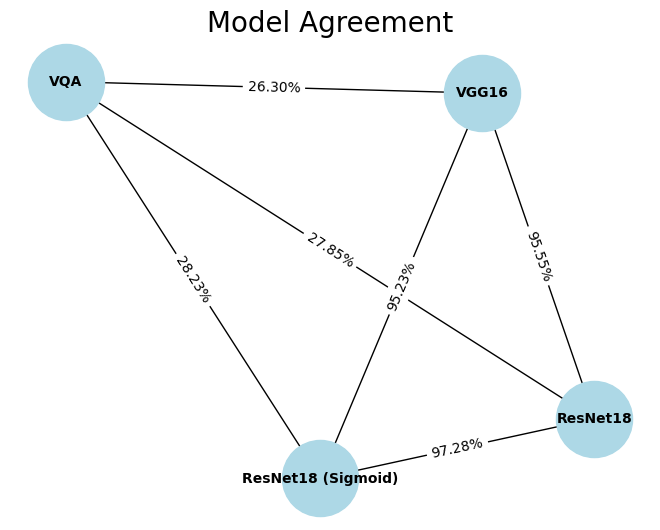

In [17]:
labels = nx.get_edge_attributes(G, 'wperc')
pos = nx.spring_layout(G, seed=42)  # positions for all nodes
nx.draw(G, pos=pos, with_labels=True, node_size=3000, node_color='lightblue', font_size=10, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=labels)
plt.title('Model Agreement', fontsize=20)
plt.show()